# 01.- Preprocesamiento de la Data

In [ ]:
# Vamos a establecer las librerias que vamos a utilizar

import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt

In [23]:
# Vamos a definir los archivos csv donde estan los datos crudos

examen2026 = pd.read_csv("./data2026.csv")
examen2025 = pd.read_csv("./data2025.csv")
examen2024 = pd.read_csv("./data2024.csv")
examen2023 = pd.read_csv("./data2023.csv")
examen2022 = pd.read_csv("./data2022.csv")
examen2021 = pd.read_csv("./data2021.csv")
examen_feb2020 = pd.read_csv("./data-feb2020.csv")
examen_jun2020 = pd.read_csv("./data-jun2020.csv")
examen_feb2019 = pd.read_csv("./data-feb2019.csv")
examen_jun2019 = pd.read_csv("./data-jun2019.csv")

/var/folders/c3/j0jrm1_52tq8r7nm40mm_l380000gn/T/ipykernel_37644/608149327.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  examen2025 = pd.read_csv("./data2025.csv")


In [24]:
examen2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167094 entries, 0 to 167093
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Area      167094 non-null  int64  
 1   Career    167094 non-null  object 
 2   Faculty   167094 non-null  object 
 3   Scores    138406 non-null  float64
 4   Accepted  167094 non-null  bool   
dtypes: bool(1), float64(1), int64(1), object(2)
memory usage: 5.3+ MB


In [25]:
print(examen2026.head(10))

   Area    Career               Faculty  Scores  Accepted
0    15  ACTUARIA  FACULTAD DE CIENCIAS    92.0     False
1    15  ACTUARIA  FACULTAD DE CIENCIAS    44.0     False
2    15  ACTUARIA  FACULTAD DE CIENCIAS    75.0     False
3    15  ACTUARIA  FACULTAD DE CIENCIAS    59.0     False
4    15  ACTUARIA  FACULTAD DE CIENCIAS    88.0     False
5    15  ACTUARIA  FACULTAD DE CIENCIAS    88.0     False
6    15  ACTUARIA  FACULTAD DE CIENCIAS    47.0     False
7    15  ACTUARIA  FACULTAD DE CIENCIAS    58.0     False
8    15  ACTUARIA  FACULTAD DE CIENCIAS    64.0     False
9    15  ACTUARIA  FACULTAD DE CIENCIAS    86.0     False


In [ ]:

# Transformamos datos crudos de examenes UNAM a datasets procesados


# Metadata de cada examen: nombre del df, año, periodo
# periodo "unica" para los años que ya solo tienen una convocatoria
examenes_meta = [
    (examen_feb2019, 2019, "feb"),
    (examen_jun2019, 2019, "jun"),
    (examen_feb2020, 2020, "feb"),
    (examen_jun2020, 2020, "jun"),
    (examen2021,      2021, "unica"),
    (examen2022,      2022, "unica"),
    (examen2023,      2023, "unica"),
    (examen2024,      2024, "unica"),
    (examen2025,      2025, "unica"),
    (examen2026,      2026, "unica"),
]

# Mapeo

area_map = {
    15: (1, "Ciencias Fisico-Matematicas y de las Ingenierias"),
    25: (2, "Ciencias Biologicas, Quimicas y de la Salud"),
    35: (3, "Ciencias Sociales"),
    45: (4, "Humanidades y Artes"),
}


# Funcion de normalizacion de texto


def normalize_text(text):
    if pd.isna(text):
        return text
    text = str(text).strip().upper()
    text = re.sub(r"\s+", " ", text)
    # quitamos acentos para que la comparacion no falle por
    # diferencias de codificacion entre archivos de distintos años
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    return text


# Construccion del dataframe long, concatenando los 10 examenes

frames = []

for df, year, period in examenes_meta:
    temp = df.copy()

    # id de examen, para periodos unica solo usamos el año
    if period == "unica":
        examen_id = f"{year}"
    else:
        examen_id = f"{year}-{period}"

    temp["examen_id"] = examen_id
    temp["year"] = year
    temp["period"] = period

    # mapeo de area, si algun valor no esta en el diccionario
    # lo dejamos como NaN para poder detectarlo despues en vez
    # de que truene el proceso
    temp["area_num"] = temp["Area"].map(lambda a: area_map.get(a, (np.nan, np.nan))[0])
    temp["area_name"] = temp["Area"].map(lambda a: area_map.get(a, (np.nan, np.nan))[1])

    temp["career_raw"] = temp["Career"]
    temp["faculty_raw"] = temp["Faculty"]
    temp["career_norm"] = temp["Career"].apply(normalize_text)
    temp["faculty_norm"] = temp["Faculty"].apply(normalize_text)

    temp["scores"] = pd.to_numeric(temp["Scores"], errors="coerce")
    temp["accepted"] = temp["Accepted"]

    # presento el examen si tiene aciertos registrados, un aspirante
    # inscrito puede no haberse presentado y por eso tener aciertos vacios
    temp["presento"] = temp["scores"].notna()

    frames.append(temp[[
        "examen_id", "year", "period",
        "area_num", "area_name",
        "career_raw", "career_norm",
        "faculty_raw", "faculty_norm",
        "scores", "accepted", "presento"
    ]])

aspirantes_long = pd.concat(frames, ignore_index=True)

print(f"Total de aspirantes en los 10 examenes: {len(aspirantes_long)}")
aspirantes_long.head()

Total de aspirantes en los 10 examenes: 1482224


,examen_id,year,period,area_num,area_name,career_raw,career_norm,faculty_raw,faculty_norm,scores,accepted,presento
0,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,ACTUARIA,ACTUARIA,FACULTAD DE CIENCIAS,FACULTAD DE CIENCIAS,71.0,False,True
1,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,ACTUARIA,ACTUARIA,FACULTAD DE CIENCIAS,FACULTAD DE CIENCIAS,91.0,False,True
2,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,ACTUARIA,ACTUARIA,FACULTAD DE CIENCIAS,FACULTAD DE CIENCIAS,57.0,False,True
3,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,ACTUARIA,ACTUARIA,FACULTAD DE CIENCIAS,FACULTAD DE CIENCIAS,36.0,False,True
4,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,ACTUARIA,ACTUARIA,FACULTAD DE CIENCIAS,FACULTAD DE CIENCIAS,98.0,False,True


In [ ]:

# Catalogo de carreras con id unico independiente del año

carreras_unicas = (
    aspirantes_long[["career_norm"]]
    .drop_duplicates()
    .sort_values("career_norm")
    .reset_index(drop=True)
)
carreras_unicas["career_id"] = carreras_unicas.index + 1

# nombre limpio para mostrar en graficas, tomamos la version
# raw mas frecuente para ese career_norm
nombre_display = (
    aspirantes_long
    .groupby(["career_norm", "career_raw"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .drop_duplicates("career_norm")
    .rename(columns={"career_raw": "career"})
    [["career_norm", "career"]]
)

catalogo_carreras = carreras_unicas.merge(nombre_display, on="career_norm", how="left")

# cuantos examenes distintos aparece cada carrera, sirve para
# detectar carreras que el scraper no logro minar en algun año
n_examenes = (
    aspirantes_long
    .groupby("career_norm")["examen_id"]
    .nunique()
    .reset_index(name="n_examenes_presente")
)

catalogo_carreras = catalogo_carreras.merge(n_examenes, on="career_norm", how="left")
catalogo_carreras = catalogo_carreras[["career_id", "career", "career_norm", "n_examenes_presente"]]

print(f"Numero de carreras distintas detectadas: {len(catalogo_carreras)}")
catalogo_carreras.head()

Numero de carreras distintas detectadas: 116


,career_id,career,career_norm,n_examenes_presente
0,1,ACTUARIA,ACTUARIA,10
1,2,ADMINISTRACION,ADMINISTRACION,10
2,3,ADMINISTRACION AGROPECUARIA,ADMINISTRACION AGROPECUARIA,10
3,4,ADMINISTRACION DE ARCHIVOS Y GESTION DOCUMENTAL,ADMINISTRACION DE ARCHIVOS Y GESTION DOCUMENTAL,10
4,5,ANTROPOLOGIA,ANTROPOLOGIA,10


In [ ]:
# Union del career_id de vuelta al dataframe long
# y armado de la version final que se guarda en disco


aspirantes_long = aspirantes_long.merge(
    catalogo_carreras[["career_id", "career", "career_norm"]],
    on="career_norm",
    how="left"
)

# dejamos faculty tambien con su version limpia, sin catalogo
# aparte por ahora, pero ya normalizada para evitar duplicados
# por espacios o acentos
aspirantes_long["faculty"] = aspirantes_long["faculty_norm"]

aspirantes_long_final = aspirantes_long[[
    "examen_id", "year", "period",
    "area_num", "area_name",
    "career_id", "career",
    "faculty",
    "scores", "accepted", "presento"
]]

aspirantes_long_final.to_csv("aspirantes_long.csv", index=False)
print("Guardado: aspirantes_long.csv")

Guardado: aspirantes_long.csv


In [29]:
aspirantes_long_final.head()

,examen_id,year,period,area_num,area_name,career_id,career,faculty,scores,accepted,presento
0,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,1,ACTUARIA,FACULTAD DE CIENCIAS,71.0,False,True
1,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,1,ACTUARIA,FACULTAD DE CIENCIAS,91.0,False,True
2,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,1,ACTUARIA,FACULTAD DE CIENCIAS,57.0,False,True
3,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,1,ACTUARIA,FACULTAD DE CIENCIAS,36.0,False,True
4,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,1,ACTUARIA,FACULTAD DE CIENCIAS,98.0,False,True


In [ ]:
# Dataframe resumen por carrera x examen
# aqui es donde van a vivir las pruebas estadisticas que
# necesitan una sola cifra por carrera y año


def resumen_grupo(g):
    n_aspirantes = len(g)
    n_presento = g["presento"].sum()
    n_seleccionados = g["accepted"].sum()

    # aciertos minimos: el minimo de aciertos entre los aceptados
    # si no hubo aceptados en el grupo, queda como NaN
    aceptados_scores = g.loc[g["accepted"], "scores"]
    aciertos_minimos = aceptados_scores.min() if len(aceptados_scores) > 0 else np.nan

    tasa_aceptacion = n_seleccionados / n_presento if n_presento > 0 else np.nan

    return pd.Series({
        "n_aspirantes": n_aspirantes,
        "n_presento": n_presento,
        "n_seleccionados": n_seleccionados,
        "aciertos_minimos": aciertos_minimos,
        "tasa_aceptacion": tasa_aceptacion,
    })

resumen_carrera_examen = (
    aspirantes_long_final
    .groupby(["examen_id", "year", "period", "area_num", "area_name", "career_id", "career", "faculty"])
    .apply(resumen_grupo)
    .reset_index()
)

resumen_carrera_examen.to_csv("resumen_carrera_examen.csv", index=False)
catalogo_carreras.to_csv("catalogo_carreras.csv", index=False)

print("Guardado: resumen_carrera_examen.csv")
print("Guardado: catalogo_carreras.csv")

resumen_carrera_examen.head()

Guardado: resumen_carrera_examen.csv
Guardado: catalogo_carreras.csv


/var/folders/c3/j0jrm1_52tq8r7nm40mm_l380000gn/T/ipykernel_37644/1926635830.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resumen_grupo)


,examen_id,year,period,area_num,area_name,career_id,career,faculty,n_aspirantes,n_presento,n_seleccionados,aciertos_minimos,tasa_aceptacion
0,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,1,ACTUARIA,FACULTAD DE CIENCIAS,1433.0,1308.0,37.0,104.0,0.028287
1,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,1,ACTUARIA,FES ACATLAN,728.0,680.0,43.0,92.0,0.063235
2,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,6,ARQUITECTURA,FACULTAD DE ARQUITECTURA,4068.0,3744.0,202.0,87.0,0.053953
3,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,6,ARQUITECTURA,FES ACATLAN,1315.0,1231.0,76.0,78.0,0.061738
4,2019-feb,2019,feb,1,Ciencias Fisico-Matematicas y de las Ingenierias,6,ARQUITECTURA,FES ARAGON,1462.0,1371.0,69.0,77.0,0.050328


In [31]:
# revisamos que valores no numericos traia Scores en cada examen
for df, year, period in examenes_meta:
    raw_scores = df["Scores"]
    no_numericos = raw_scores[pd.to_numeric(raw_scores, errors="coerce").isna() & raw_scores.notna()]
    if len(no_numericos) > 0:
        print(f"{year}-{period}: valores no numericos encontrados -> {no_numericos.unique()}")

2025-unica: valores no numericos encontrados -> ['E']


In [ ]:
# Chequeos rapidos de salud genral del df

# areas que no se pudieron mapear
sin_area = aspirantes_long_final["area_num"].isna().sum()
print(f"Renglones sin area mapeada: {sin_area}")

# carreras aceptadas sin aciertos registrados, no deberia pasar
inconsistentes = aspirantes_long_final[
    (aspirantes_long_final["accepted"]) & (aspirantes_long_final["scores"].isna())
]
print(f"Aceptados sin aciertos registrados: {len(inconsistentes)}")

# cuantas carreras aparecen en pocos examenes, candidatas a revisar
# si es un cambio real de nombre que la normalizacion no capturo
pocos_examenes = catalogo_carreras[catalogo_carreras["n_examenes_presente"] <= 8]
print(f"Carreras presentes en 7 examenes o menos: {len(pocos_examenes)}")
pocos_examenes.head(10)

Renglones sin area mapeada: 0
Aceptados sin aciertos registrados: 1
Carreras presentes en 7 examenes o menos: 12


,career_id,career,career_norm,n_examenes_presente
14,15,CIENCIAS AGROFORESTALES,CIENCIAS AGROFORESTALES,8
15,16,CIENCIAS AGROGENOMICAS,CIENCIAS AGROGENOMICAS,2
33,34,ECOLOGIA,ECOLOGIA,5
56,57,INGENIERIA AEROESPACIAL,INGENIERIA AEROESPACIAL,7
64,65,INGENIERIA EN ENERGIAS RENOVABLES,INGENIERIA EN ENERGIAS RENOVABLES,1
65,66,INGENIERIA EN TELECOMUNICACIONES,INGENIERIA EN TELECOMUNICACIONES,3
90,91,MATEMATICAS PARA EL DESARROLLO,MATEMATICAS PARA EL DESARROLLO,2
97,98,ORTESIS Y PROTESIS,ORTESIS Y PROTESIS,2
108,109,SOCIOLOGIA APLICADA,SOCIOLOGIA APLICADA,3
109,110,TEATRO Y ACTUACION,TEATRO Y ACTUACION,8


## EDA Rapido

### Exploratory Data Analysis de lo que ya vimos en redes sociales para ver que todo vaya bien

In [ ]:
# primero verificamos que valores de faculty existen para
# Medico Cirujano, para confirmar cual corresponde a CU
medicina_facultades = aspirantes_long_final[
    aspirantes_long_final["career"] == "MEDICO CIRUJANO"
]["faculty"].unique()

print("Facultades encontradas para Medico Cirujano:")
print(medicina_facultades)

Facultades encontradas para Medico Cirujano:
['FACULTAD DE MEDICINA' 'FES IZTACALA' 'FES ZARAGOZA']


In [36]:
# lista de examenes en orden cronologico
orden_examenes = [
    "2019-feb", "2019-jun",
    "2020-feb", "2020-jun",
    "2021", "2022", "2023", "2024", "2025", "2026"
]

# filtramos medico cirujano cu, solo quienes presentaron
medicina_cu = aspirantes_long_final[
    (aspirantes_long_final["career"] == "MEDICO CIRUJANO") &
    (aspirantes_long_final["faculty"] == "FACULTAD DE MEDICINA") &
    (aspirantes_long_final["scores"].notna())
]

# conteo de aspirantes por examen, util para poner en el titulo
# de cada panel y para detectar algun año con muy pocos datos
conteos = medicina_cu.groupby("examen_id")["scores"].count()
print(conteos.reindex(orden_examenes))

examen_id
2019-feb    10260
2019-jun     3434
2020-feb    10744
2020-jun     3616
2021        12384
2022        13936
2023        13275
2024        12458
2025        13626
2026        13144
Name: scores, dtype: int64


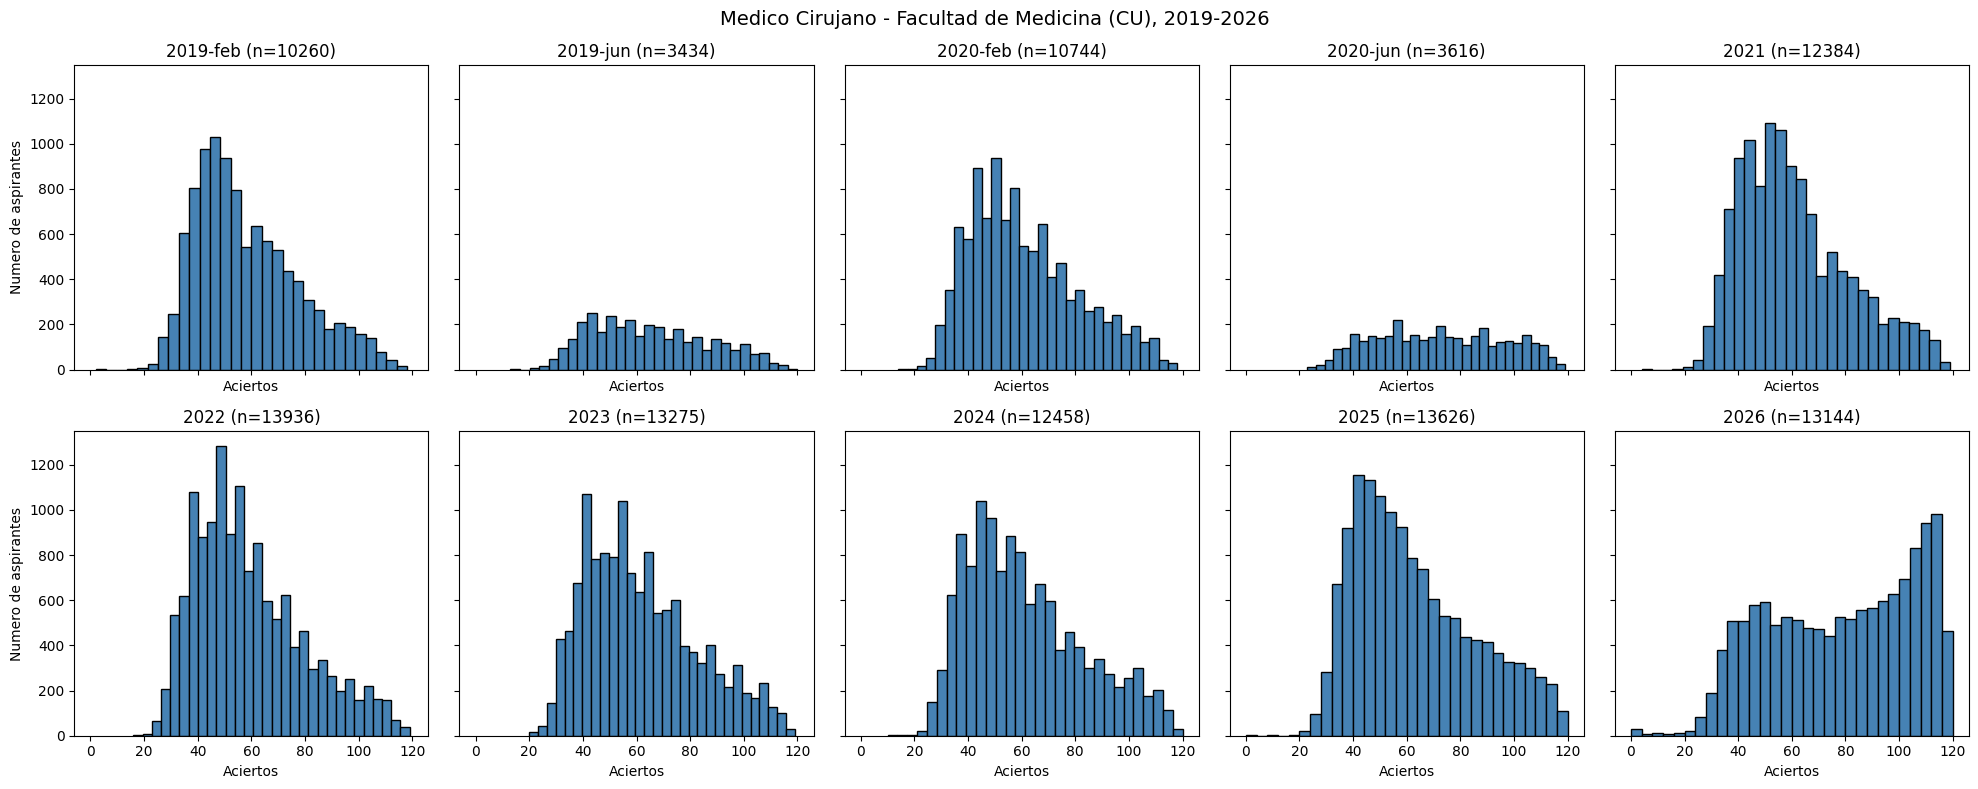

In [ ]:
# grid de histogramas, un panel por examen
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, examen_id in enumerate(orden_examenes):
    data = medicina_cu[medicina_cu["examen_id"] == examen_id]["scores"]
    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{examen_id})")
    axes[i].set_xlabel("Aciertos")
    if i % 5 == 0:
        axes[i].set_ylabel("Numero de aspirantes")

plt.suptitle("Medico Cirujano - Facultad de Medicina (CU), 2019-2026", fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
# filtramos derecho en la facultad de derecho, solo quienes presentaron
derecho = aspirantes_long_final[
    (aspirantes_long_final["career"] == "DERECHO") &
    (aspirantes_long_final["faculty"] == "FACULTAD DE DERECHO") &
    (aspirantes_long_final["scores"].notna())
]

# conteo de aspirantes por examen, para revisar antes de graficar
conteos_derecho = derecho.groupby("examen_id")["scores"].count()
print(conteos_derecho.reindex(orden_examenes))

examen_id
2019-feb    4493
2019-jun    2044
2020-feb    4311
2020-jun    1913
2021        5139
2022        5711
2023        5536
2024        5260
2025        6089
2026        4935
Name: scores, dtype: int64


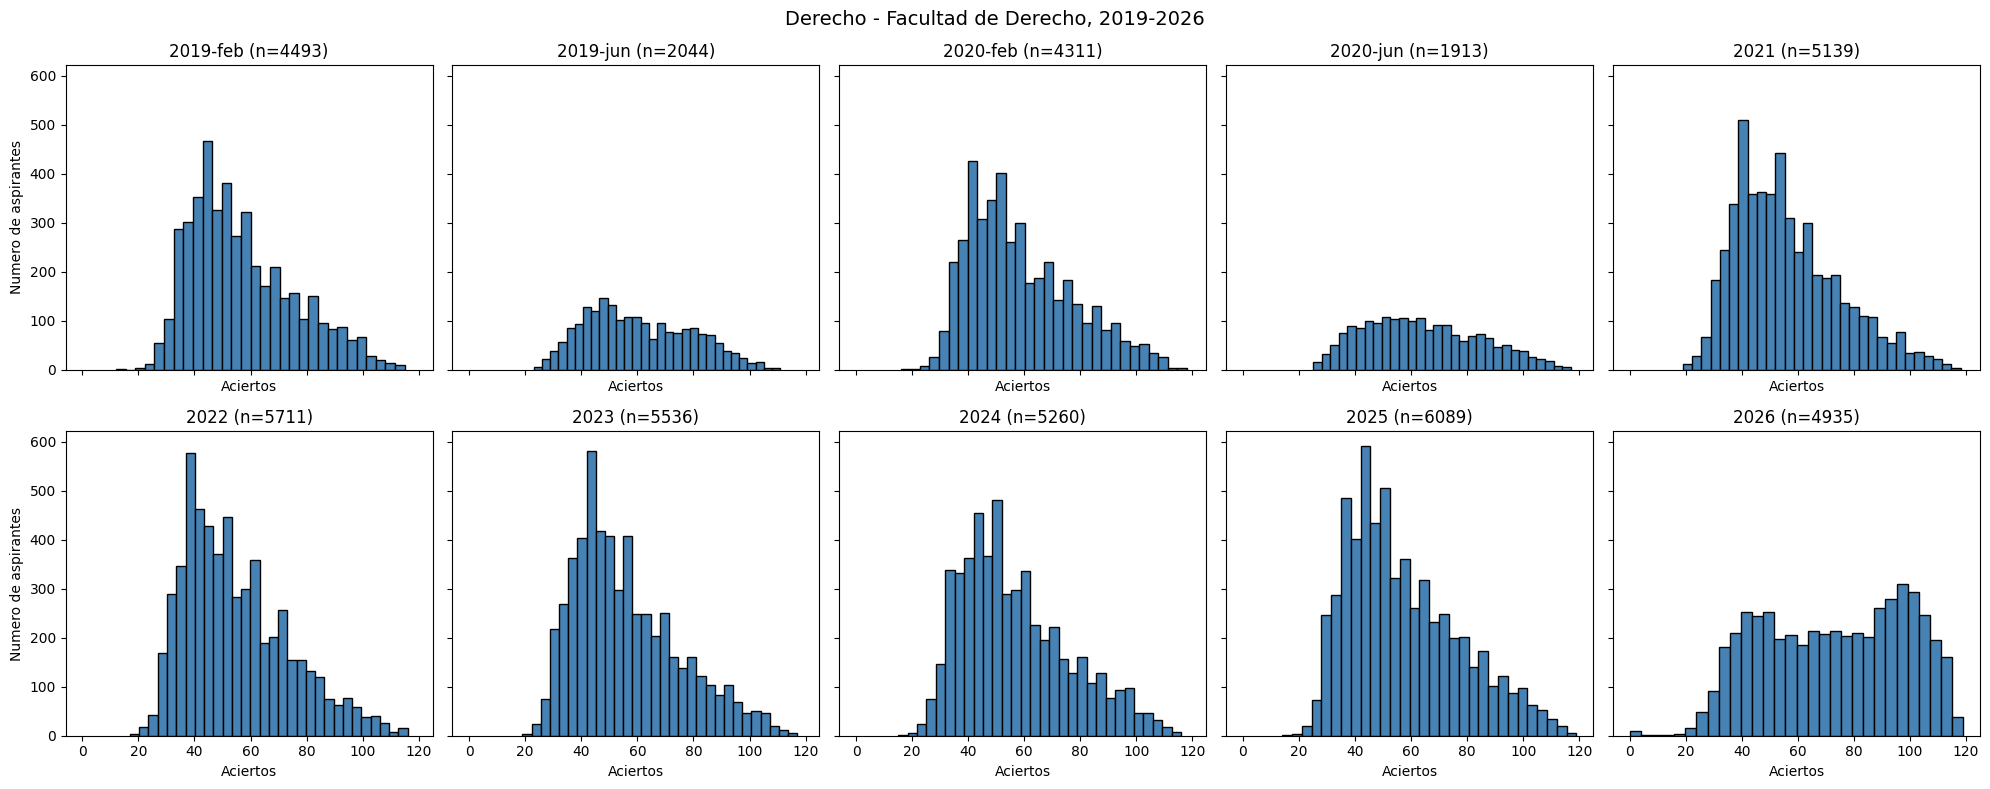

In [39]:
# grid de histogramas, un panel por examen
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, examen_id in enumerate(orden_examenes):
    data = derecho[derecho["examen_id"] == examen_id]["scores"]
    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{examen_id} (n={len(data)})")
    axes[i].set_xlabel("Aciertos")
    if i % 5 == 0:
        axes[i].set_ylabel("Numero de aspirantes")

plt.suptitle("Derecho - Facultad de Derecho, 2019-2026", fontsize=14)
plt.tight_layout()
plt.show()

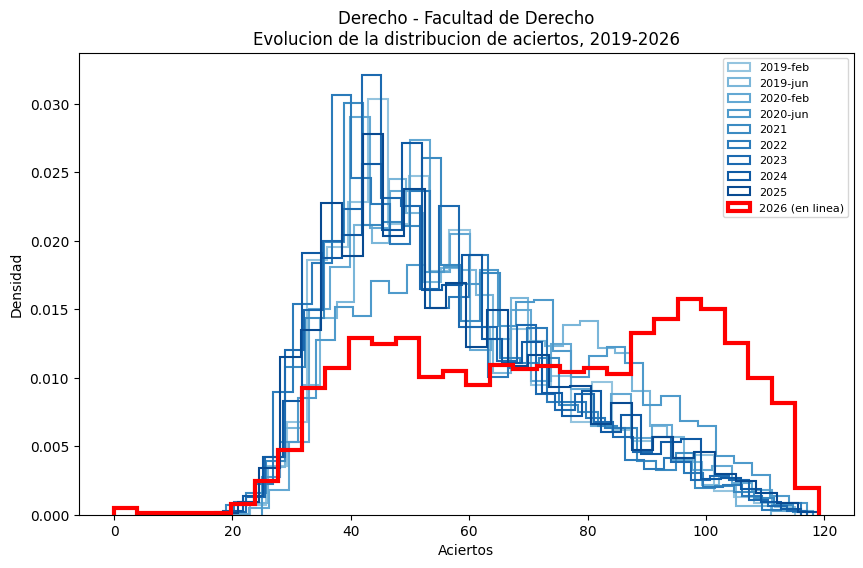

In [40]:
# version superpuesta con densidad, 2026 resaltado en rojo
plt.figure(figsize=(10, 6))

colores_historicos = plt.cm.Blues(np.linspace(0.4, 0.9, len(orden_examenes) - 1))

for examen_id, color in zip(orden_examenes[:-1], colores_historicos):
    data = derecho[derecho["examen_id"] == examen_id]["scores"]
    plt.hist(data, bins=30, density=True, histtype="step",
              linewidth=1.5, color=color, label=examen_id)

data_2026 = derecho[derecho["examen_id"] == "2026"]["scores"]
plt.hist(data_2026, bins=30, density=True, histtype="step",
          linewidth=3, color="red", label="2026 (en linea)")

plt.xlabel("Aciertos")
plt.ylabel("Densidad")
plt.title("Derecho - Facultad de Derecho\nEvolucion de la distribucion de aciertos, 2019-2026")
plt.legend(fontsize=8)
plt.show()

In [41]:
# facultades que imparten medico cirujano
medicina_facultades = aspirantes_long_final[
    aspirantes_long_final["career"] == "MEDICO CIRUJANO"
]["faculty"].unique()

print(medicina_facultades)

['FACULTAD DE MEDICINA' 'FES IZTACALA' 'FES ZARAGOZA']


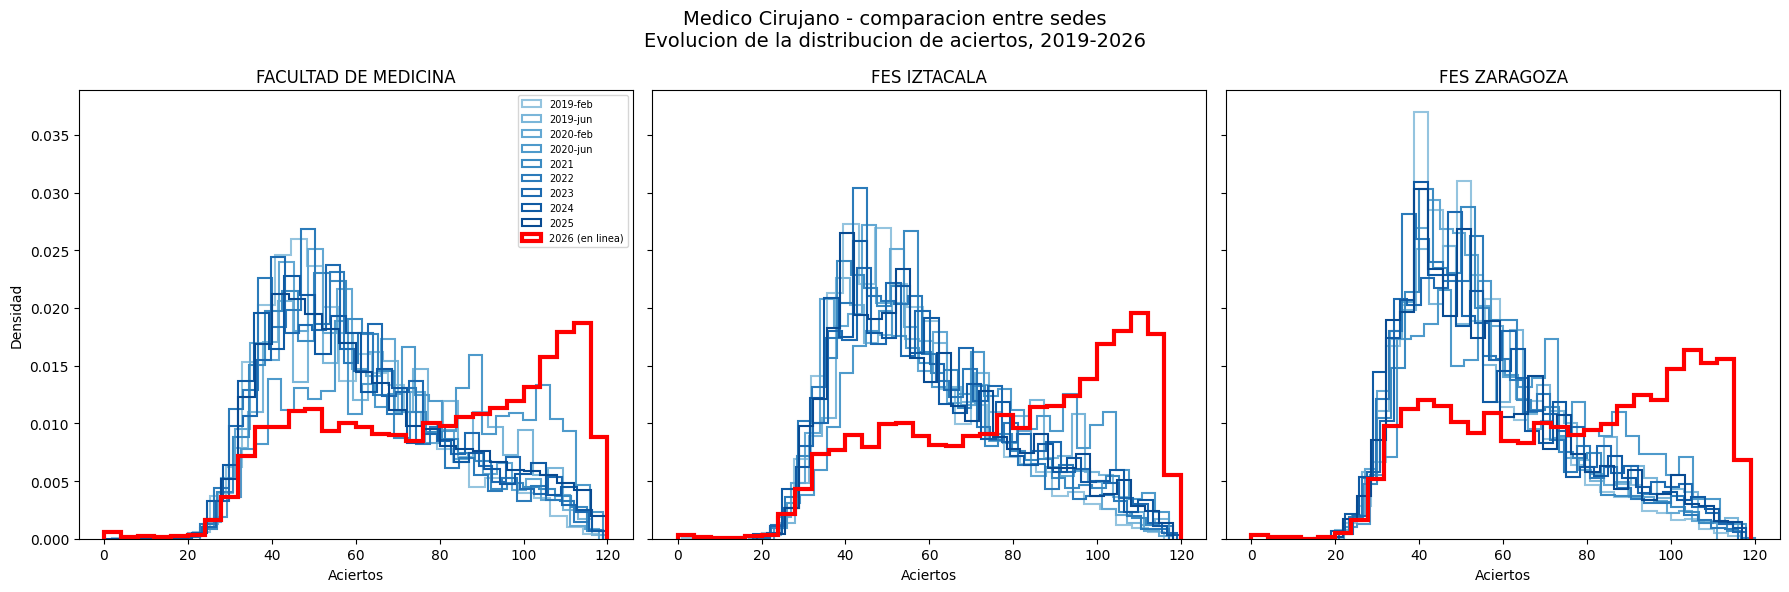

In [42]:
# lista de facultades/sedes que imparten medico cirujano
# ajusta estos nombres segun lo que haya salido en el print de arriba
sedes_medicina = medicina_facultades.tolist()

fig, axes = plt.subplots(1, len(sedes_medicina), figsize=(6 * len(sedes_medicina), 6), sharey=True)

# si solo hay una sede, axes no viene como lista, lo forzamos
if len(sedes_medicina) == 1:
    axes = [axes]

colores_historicos = plt.cm.Blues(np.linspace(0.4, 0.9, len(orden_examenes) - 1))

for ax, sede in zip(axes, sedes_medicina):
    data_sede = aspirantes_long_final[
        (aspirantes_long_final["career"] == "MEDICO CIRUJANO") &
        (aspirantes_long_final["faculty"] == sede) &
        (aspirantes_long_final["scores"].notna())
    ]

    for examen_id, color in zip(orden_examenes[:-1], colores_historicos):
        data = data_sede[data_sede["examen_id"] == examen_id]["scores"]
        if len(data) > 0:
            ax.hist(data, bins=30, density=True, histtype="step",
                     linewidth=1.5, color=color, label=examen_id)

    data_2026 = data_sede[data_sede["examen_id"] == "2026"]["scores"]
    ax.hist(data_2026, bins=30, density=True, histtype="step",
             linewidth=3, color="red", label="2026 (en linea)")

    ax.set_title(sede)
    ax.set_xlabel("Aciertos")

axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=7)

plt.suptitle("Medico Cirujano - comparacion entre sedes\nEvolucion de la distribucion de aciertos, 2019-2026", fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
# facultades que imparten mmatematicas aplicadas
ma_facultades = aspirantes_long_final[
    aspirantes_long_final["career"] == "MATEMATICAS APLICADAS"
]["faculty"].unique()

print(ma_facultades)

['FACULTAD DE CIENCIAS']


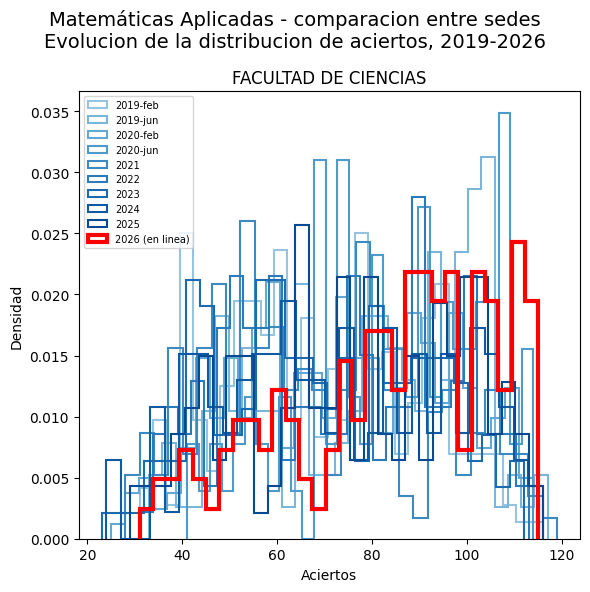

In [46]:
# lista de facultades/sedes que imparten matematicas aplicadas
# ajusta estos nombres segun lo que haya salido en el print de arriba
sedes_ma = ma_facultades.tolist()

fig, axes = plt.subplots(1, len(sedes_ma), figsize=(6 * len(sedes_ma), 6), sharey=True)

# si solo hay una sede, axes no viene como lista, lo forzamos
if len(sedes_ma) == 1:
    axes = [axes]

colores_historicos = plt.cm.Blues(np.linspace(0.4, 0.9, len(orden_examenes) - 1))

for ax, sede in zip(axes, sedes_ma):
    data_sede = aspirantes_long_final[
        (aspirantes_long_final["career"] == "MATEMATICAS APLICADAS") &
        (aspirantes_long_final["faculty"] == sede) &
        (aspirantes_long_final["scores"].notna())
    ]

    for examen_id, color in zip(orden_examenes[:-1], colores_historicos):
        data = data_sede[data_sede["examen_id"] == examen_id]["scores"]
        if len(data) > 0:
            ax.hist(data, bins=30, density=True, histtype="step",
                     linewidth=1.5, color=color, label=examen_id)

    data_2026 = data_sede[data_sede["examen_id"] == "2026"]["scores"]
    ax.hist(data_2026, bins=30, density=True, histtype="step",
             linewidth=3, color="red", label="2026 (en linea)")

    ax.set_title(sede)
    ax.set_xlabel("Aciertos")

axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=7)

plt.suptitle("Matemáticas Aplicadas - comparacion entre sedes\nEvolucion de la distribucion de aciertos, 2019-2026", fontsize=14)
plt.tight_layout()
plt.show()